# Model v4 — No CPI, Full History (2006–2023)

## What we tried

v3 used maize-specific CPI from UBOS as its most important feature (59% importance), but CPI only
goes back to July 2017, limiting training to 65 rows. We asked: what if we drop CPI and use
two external economic features that go back to 2006?

**Changes from v3:**
- Drop maize CPI as a feature entirely
- Add **World Bank global maize price** (USD/tonne, monthly — World Bank Pink Sheet, 1960–2024)
- Add **World Bank FX rate** (UGX/USD, annual average — World Bank API, 1960–2024)
- Train on full WFP price history: **2010–2023 (155 rows vs 65 in v3)**

## Why we thought this would help
- More price cycles in training → model sees prices go up AND come down
- FX and global maize price are **leading indicators** (cause prices to change), not lagging like CPI
- Removing the 2017 CPI constraint unlocks ~90 more training rows

## What we found
- **MAE 223** — essentially identical to v3 (224). Tripling training data moved the needle by 1 UGX/kg.
- The naive baseline (rolling mean 3, MAE 196) still wins.
- Feature importances: `price_lag_1` (38%) dominates. FX and global maize scored only 6.5% and 4.2%.
- The problem is not the features or the training window — it's the model type. See findings at the end.

## 1. Load WFP Maize Prices

In [2]:
import pandas as pd
import numpy as np
from huggingface_hub import hf_hub_download

prices_path = hf_hub_download(
    repo_id="byabasaija/uganda-maize-prices",
    filename="uganda_maize_prices_owino.csv",
    repo_type="dataset",
)
prices_df = pd.read_csv(prices_path)
prices_df["date"] = pd.to_datetime(prices_df[["year", "month"]].assign(day=1))
prices_df = prices_df.sort_values("date").reset_index(drop=True)

print(f"WFP prices: {prices_df['date'].min().date()} to {prices_df['date'].max().date()}")
print(f"Rows: {len(prices_df)}")
prices_df[["date", "year", "month", "price"]].head()

WFP prices: 2010-01-01 to 2025-04-01
Rows: 177


,date,year,month,price
0,2010-01-01,2010,1,975.0
1,2010-02-01,2010,2,850.0
2,2010-03-01,2010,3,1000.0
3,2010-04-01,2010,4,825.0
4,2010-05-01,2010,5,800.0


## 2. Load Global Maize Price (World Bank Pink Sheet)

Monthly international maize price in USD/tonne from CME (Chicago Mercantile Exchange).
This is the world market price — a leading indicator of what Uganda pays for imports.

In [3]:
import requests, io

resp = requests.get(
    "https://thedocs.worldbank.org/en/doc/5d903e848db1d1b83e0ec8f744e55570-0350012021/related/CMO-Historical-Data-Monthly.xlsx",
    timeout=60,
)
resp.raise_for_status()

raw = pd.read_excel(io.BytesIO(resp.content), sheet_name="Monthly Prices", header=4)
raw = raw.rename(columns={"Unnamed: 0": "date"})
raw = raw[raw["date"].notna() & raw["date"].astype(str).str.match(r"\d{4}M\d{2}")]
raw["date"] = pd.to_datetime(raw["date"].astype(str).str.replace("M", "-"), format="%Y-%m")

global_maize = raw[["date", "Maize"]].rename(columns={"Maize": "global_maize_usd"}).dropna().sort_values("date")

print(f"Global maize price: {global_maize['date'].min().date()} to {global_maize['date'].max().date()}")
print(f"Rows: {len(global_maize)}")
global_maize[global_maize["date"].dt.year >= 2005].head(6)

Global maize price: 1960-01-01 to 2024-12-01
Rows: 780


,date,global_maize_usd
541,2005-01-01,96.25476
542,2005-02-01,94.13873
543,2005-03-01,99.876616
544,2005-04-01,96.279365
545,2005-05-01,95.41819
546,2005-06-01,97.101172


## 3. Load FX Rate (World Bank, annual UGX/USD)

Annual average exchange rate from World Bank (PA.NUS.FCRF).
This is factual data — the measured annual average, not interpolated monthly values.

In [4]:
resp = requests.get(
    "https://api.worldbank.org/v2/country/UGA/indicator/PA.NUS.FCRF",
    params={"format": "json", "per_page": 100},
    timeout=30,
)
resp.raise_for_status()

records = [r for r in resp.json()[1] if r["value"] is not None]
fx_df = pd.DataFrame([
    {"year": int(r["date"]), "fx_ugx_usd": r["value"]}
    for r in records
]).sort_values("year").reset_index(drop=True)

print(f"FX data: {fx_df['year'].min()} to {fx_df['year'].max()} ({len(fx_df)} annual values)")
print("Note: annual average — each month in a year gets the same value")
fx_df[fx_df["year"] >= 2005]

FX data: 1960 to 2024 (65 annual values)
Note: annual average — each month in a year gets the same value


,year,fx_ugx_usd
45,2005,1780.540261
46,2006,1831.451851
47,2007,1723.491587
48,2008,1720.443879
49,2009,2030.488074
50,2010,2177.557507
51,2011,2522.802033
52,2012,2504.563078
53,2013,2586.889569
54,2014,2599.788201


## 4. Merge All Data

In [5]:
# Merge global maize price (monthly) onto prices
merged = prices_df.merge(global_maize, on="date", how="inner")

# Merge FX (annual) by year
merged = merged.merge(fx_df, on="year", how="inner")
merged = merged.sort_values("date").reset_index(drop=True)

print(f"After merge: {len(merged)} rows")
print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")
merged[["date", "price", "global_maize_usd", "fx_ugx_usd"]].head()

After merge: 173 rows
Date range: 2010-01-01 to 2024-12-01


,date,price,global_maize_usd,fx_ugx_usd
0,2010-01-01,975.0,167.314,2177.557507
1,2010-02-01,850.0,161.80248,2177.557507
2,2010-03-01,1000.0,159.04672,2177.557507
3,2010-04-01,825.0,157.07832,2177.557507
4,2010-05-01,800.0,163.3772,2177.557507


## 5. Build Feature Matrix

In [ ]:
import sys
sys.path.insert(0, "../food_prices_api")
from features import compute_features

prices_series = merged["price"].tolist()
feature_rows = []
targets = []

for i in range(6, len(merged)):
    past_prices = prices_series[i - 6: i]
    row = merged.iloc[i]
    feats = compute_features(past_prices, int(row["month"]), int(row["year"]))
    feats["global_maize_usd"] = row["global_maize_usd"]
    feats["fx_ugx_usd"] = row["fx_ugx_usd"]
    feature_rows.append(feats)
    targets.append(prices_series[i])

FEATURE_COLS = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "rolling_mean_3", "rolling_mean_6",
    "month", "year",
    "global_maize_usd", "fx_ugx_usd",
]

X = pd.DataFrame(feature_rows)[FEATURE_COLS]
y = pd.Series(targets)
merged_trimmed = merged.iloc[6:].reset_index(drop=True)

print(f"Feature matrix: {X.shape}")
print(f"Features: {FEATURE_COLS}")
X.head()

## 6. Train/Test Split

Same test set as v3 for apples-to-apples comparison: Jan 2024 – Apr 2025.

In [15]:
train_mask = merged_trimmed["year"] <= 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train)} rows  ({merged_trimmed[train_mask]['date'].min().date()} to {merged_trimmed[train_mask]['date'].max().date()})")
print(f"Test:  {len(X_test)} rows  ({merged_trimmed[~train_mask]['date'].min().date()} to {merged_trimmed[~train_mask]['date'].max().date()})")
print(f"\nv3 had 65 train rows — v4 has {len(X_train)}")

Train: 155 rows  (2010-07-01 to 2023-12-01)
Test:  12 rows  (2024-01-01 to 2024-12-01)

v3 had 65 train rows — v4 has 155


## 7. Train and Evaluate

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.0f} UGX/kg")
print(f"R²  : {r2:.4f}")
print()
print("Comparison:")
print(f"  Naive baseline (rolling mean 3) : 196 UGX/kg")
print(f"  v3 (maize CPI, 65 train rows)   : 224 UGX/kg")
print(f"  v4 (FX + global maize, {len(X_train)} rows) : {mae:,.0f} UGX/kg")

MAE : 269 UGX/kg
R²  : -2.2985

Comparison:
  Naive baseline (rolling mean 3) : 196 UGX/kg
  v3 (maize CPI, 65 train rows)   : 224 UGX/kg
  v4 (FX + global maize, 155 rows) : 269 UGX/kg


## 8. Feature Importance

In [17]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("Feature importances:")
for name, score in importances.items():
    bar = "█" * int(score * 40)
    print(f"  {score:.4f}  {bar}  {name}")

Feature importances:
  0.4128  ████████████████  price_lag_1
  0.1791  ███████  rolling_mean_3
  0.1562  ██████  year
  0.0749  ██  rolling_mean_6
  0.0719  ██  price_lag_2
  0.0448  █  fx_ugx_usd
  0.0304  █  month
  0.0299  █  price_lag_3


## 9. Save Model

In [18]:
import joblib

joblib.dump(model, "maize_price_model_v4.pkl")
print("Saved → maize_price_model_v4.pkl")
print()
print("Next steps if v4 improves on v3:")
print("  1. Upload v4 to HuggingFace model repo")
print("  2. Update API to load v4 + fetch global_maize_usd and fx_ugx_usd at predict time")
print("  3. Update MODEL_BENCHMARKS.md")

Saved → maize_price_model_v4.pkl

Next steps if v4 improves on v3:
  1. Upload v4 to HuggingFace model repo
  2. Update API to load v4 + fetch global_maize_usd and fx_ugx_usd at predict time
  3. Update MODEL_BENCHMARKS.md


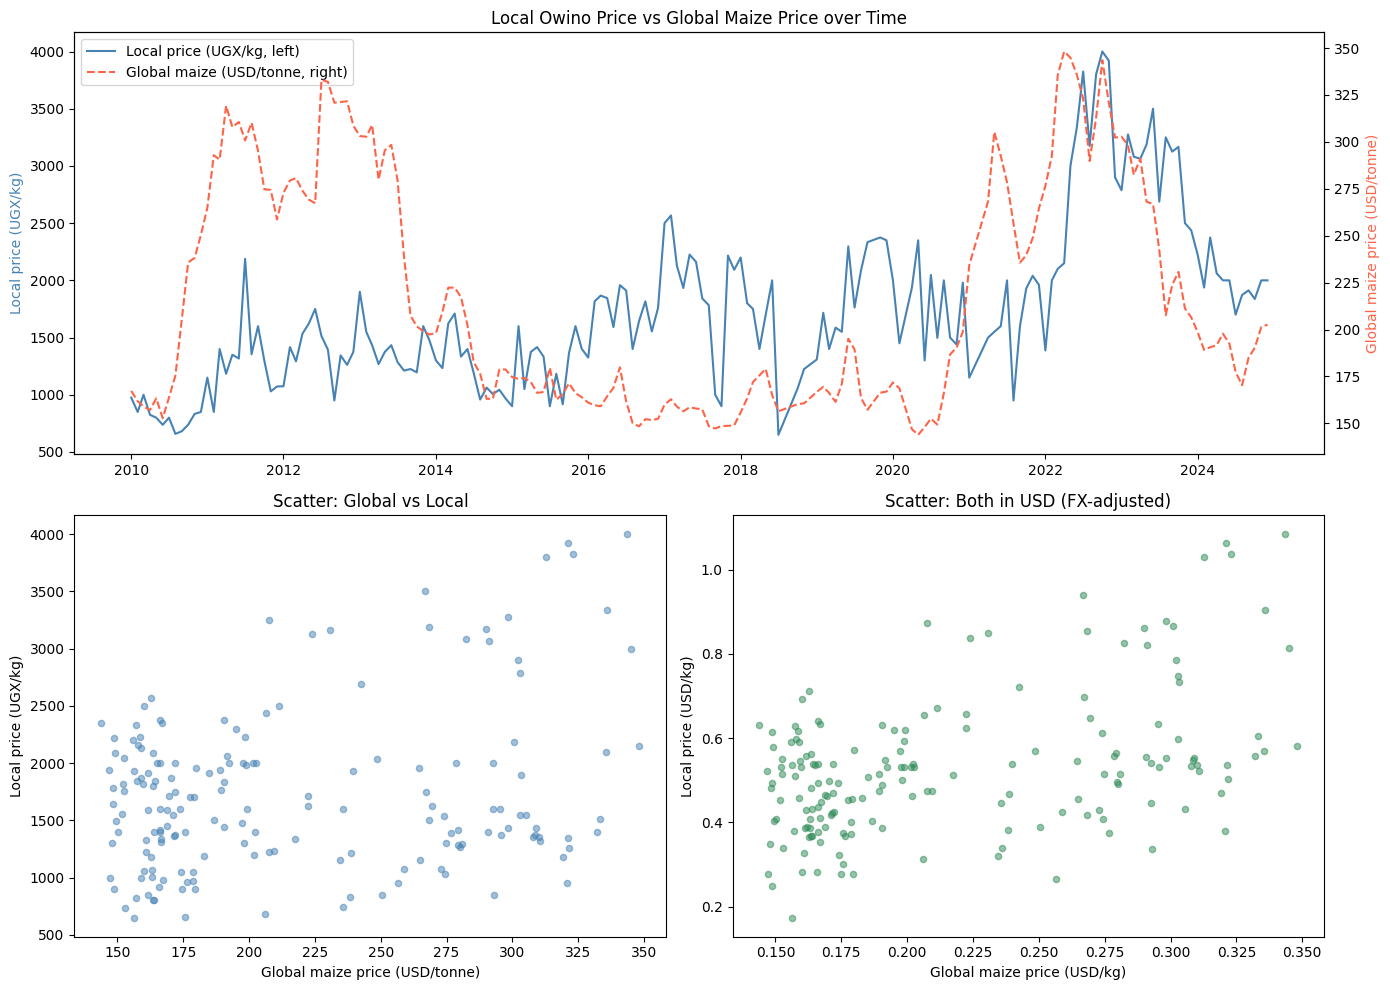

Correlation analysis:
  Raw correlation (UGX vs USD/tonne)     : +0.260
  FX-adjusted (both in USD)              : +0.455
  Year-over-year change (detrended)      : +0.275  ← most honest

Interpretation:
  Moderate relationship. Some signal but probably not dominant.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# --- 1. Price over time (dual axis) ---
ax1 = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()

ax1.plot(merged["date"], merged["price"], color="steelblue", label="Local price (UGX/kg, left)")
ax1b.plot(merged["date"], merged["global_maize_usd"], color="tomato", linestyle="--", label="Global maize (USD/tonne, right)")

ax1.set_ylabel("Local price (UGX/kg)", color="steelblue")
ax1b.set_ylabel("Global maize price (USD/tonne)", color="tomato")
ax1.set_title("Local Owino Price vs Global Maize Price over Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# --- 2. Scatter plot ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(merged["global_maize_usd"], merged["price"], alpha=0.5, color="steelblue", s=20)
ax2.set_xlabel("Global maize price (USD/tonne)")
ax2.set_ylabel("Local price (UGX/kg)")
ax2.set_title("Scatter: Global vs Local")

# --- 3. Scatter plot with FX removed (convert local to USD for fair comparison) ---
ax3 = fig.add_subplot(gs[1, 1])
merged["price_usd"] = merged["price"] / merged["fx_ugx_usd"]  # local price in USD/kg
ax3.scatter(merged["global_maize_usd"] / 1000, merged["price_usd"], alpha=0.5, color="seagreen", s=20)
ax3.set_xlabel("Global maize price (USD/kg)")
ax3.set_ylabel("Local price (USD/kg)")
ax3.set_title("Scatter: Both in USD (FX-adjusted)")

plt.tight_layout()
plt.savefig("global_vs_local_maize.png", dpi=130)
plt.show()

# --- Correlation numbers ---
pearson = merged["price"].corr(merged["global_maize_usd"])
pearson_usd = merged["price_usd"].corr(merged["global_maize_usd"] / 1000)

# Remove shared time trend (detrend with year-over-year diff)
merged["price_yoy"] = merged["price"].pct_change(12)
merged["global_yoy"] = merged["global_maize_usd"].pct_change(12)
pearson_detrended = merged["price_yoy"].corr(merged["global_yoy"])

print("Correlation analysis:")
print(f"  Raw correlation (UGX vs USD/tonne)     : {pearson:+.3f}")
print(f"  FX-adjusted (both in USD)              : {pearson_usd:+.3f}")
print(f"  Year-over-year change (detrended)      : {pearson_detrended:+.3f}  ← most honest")
print()
print("Interpretation:")
if abs(pearson_detrended) < 0.2:
    print("  Weak or no real relationship. Global maize price is not a useful feature.")
    print("  Raw correlation is likely spurious (both trend upward due to inflation).")
elif abs(pearson_detrended) < 0.4:
    print("  Moderate relationship. Some signal but probably not dominant.")
else:
    print("  Strong relationship. Global price is a genuine signal for local price.")

## 10. What We Learned

### The result
MAE 223 — one UGX better than v3. Not meaningful progress despite tripling training data and replacing CPI
with two new economic features.

### Why adding more data and better features didn't help

**Random Forest cannot extrapolate.** It predicts values within the range it was trained on.
The 2022–2023 price spike (prices reaching 2800–3500 UGX/kg) is in all training sets.
When prices corrected back to 1700–2000 in 2024, every RF model kept predicting "high"
because that's the only range it knew. No amount of extra rows or new features fixes this —
it's a structural limitation of tree-based models.

**Why FX and global maize scored low (6.5% and 4.2%):**
These are good economic signals in theory, but their effect on local Owino market prices
is delayed and indirect. By the time global prices affect a Kampala market, the signal is
already in last month's local price. `price_lag_1` (38%) captures that more directly.

### The naive baseline wins — and that's a lesson, not a failure

`rolling_mean_3` (average of last 3 months) has MAE 196. It wins because:
- Maize prices are strongly mean-reverting in the short term
- Last month's price is the best single predictor of next month's price
- When the model tries to add complexity on top, it learns noise instead of signal

This is documented in forecasting research (Makridakis M-competitions): on short time
series with high autocorrelation, simple baselines consistently outperform ML.

### What would actually help
1. **Much more data** — 15+ years of monthly prices is still only ~180 rows for ML. Thousands of rows
   would change the picture.
2. **A sequence model (LSTM)** — processes prices as a sequence, can learn that "after a multi-year spike,
   prices tend to correct." Requires more data to train well.
3. **More markets** — adding Gulu, Jinja, Mbarara gives the model more examples of price cycles.
4. **Accept the naive baseline** — ship the product, document the finding, and revisit when more data exists.